#  Bureaux — Location Marrakech

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline.locations.pip_bureaux import (
    load_data, split_and_encode, build_pipeline, train, evaluate,
    tune_hyperparams, plot_results, predict_price,
    DATA_PATH, MODEL_PATH,
    NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES,
)

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
print(" Imports OK")
print(f"   DATA  : {DATA_PATH}")
print(f"   MODEL : {MODEL_PATH}")


 Imports OK
   DATA  : /home/nouhayla/Desktop/stage/gateone-deploy/data/marrakech_immo_location/bureaux_location.csv
   MODEL : /home/nouhayla/Desktop/stage/gateone-deploy/model_training/models/xgb_bureaux_location.pkl


## 1. Aperçu des données brutes

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape brut : {df_raw.shape}")
df_raw.head(3)


Shape brut : (715, 34)


,id,titre,prix,localisation,type_bien,surface,chambres,salles_bain,description,agence,...,etage,surface_terrain,prix_num,surface_num,chambres_num,salles_bain_num,nb_pieces,quartier,prix_m2,prix_m2_median_quartier
0,8139636.0,Bureau à louer plien Gueliz,6 500 DH,"Guéliz, Marrakech",Appartement,73 m²,NaN,1 Salle de bain,NaN,Particulier,...,-1,NaN,6500.0,73.0,0.0,1.0,2.0,Guéliz,89.041096,127.102564
1,8252878.0,Bureaux à louer à Guéliz. Surface totale 142m²,17 500 DH,"Guéliz, Marrakech",Appartement,142 m²,NaN,2 Salles de bains,NaN,Particulier,...,-1,NaN,17500.0,142.0,0.0,2.0,3.0,Guéliz,123.239437,127.102564
2,8279141.0,Très grande bureaux à Marrakech,50 000 DH,"Camp Al Ghoul, Marrakech",Appartement,330 m²,NaN,2 Salles de bains,NaN,Particulier,...,-1,NaN,50000.0,330.0,0.0,2.0,3.0,Autre,151.515152,120.000000


In [3]:
print("Distribution type_bien :", df_raw["type_bien"].value_counts().to_string())
print("\nDistribution quartier :\n", df_raw["quartier"].value_counts().head(10).to_string())
print("\nNulls:", df_raw.isnull().sum()[df_raw.isnull().sum() > 0].to_string())


Distribution type_bien : type_bien
Bureaux        506
Appartement    209

Distribution quartier :
 quartier
Autre                  320
Guéliz                 306
M'hamid                 25
Hivernage               23
Targa                   13
Route de Casablanca     10
Daoudiate                7
Ménara                   7
Route d'Ourika           2
Agdal                    2

Nulls: id                 468
surface             56
chambres           685
salles_bain         79
description        209
agence             469
surface_terrain    715
prix_num            53
surface_num         56
prix_m2             97


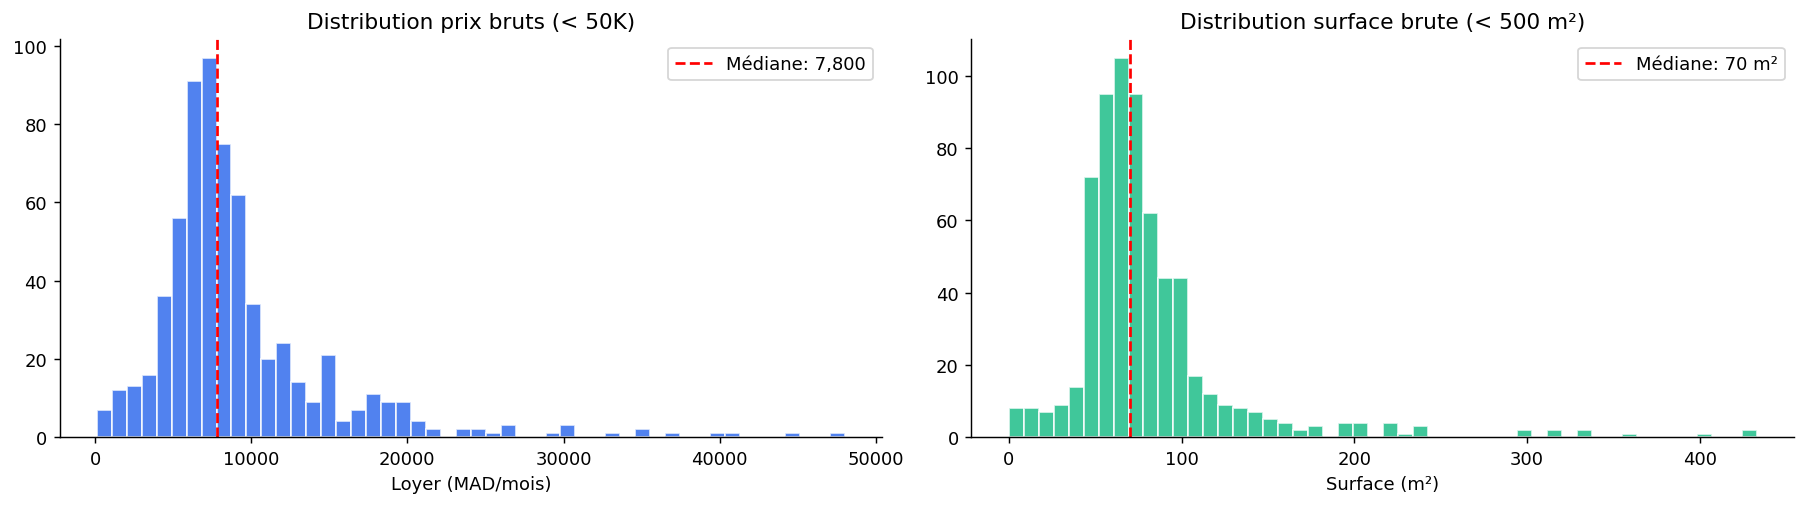

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
valid_prix = df_raw["prix_num"].dropna()
axes[0].hist(valid_prix[valid_prix < 50_000], bins=50, color="#2563eb", alpha=0.8, edgecolor="white")
axes[0].axvline(valid_prix.median(), color="red", ls="--", label=f"Médiane: {valid_prix.median():,.0f}")
axes[0].set_xlabel("Loyer (MAD/mois)"); axes[0].set_title("Distribution prix bruts (< 50K)"); axes[0].legend()

valid_surf = df_raw["surface_num"].dropna()
axes[1].hist(valid_surf[valid_surf < 500], bins=50, color="#10b981", alpha=0.8, edgecolor="white")
axes[1].axvline(valid_surf.median(), color="red", ls="--", label=f"Médiane: {valid_surf.median():.0f} m²")
axes[1].set_xlabel("Surface (m²)"); axes[1].set_title("Distribution surface brute (< 500 m²)"); axes[1].legend()
plt.tight_layout(); plt.show()


## 2. Nettoyage & Feature Engineering

In [5]:
df = load_data(DATA_PATH)
print(f"\nShape après nettoyage : {df.shape}")
print(f"Loyer médian : {df['prix_num'].median():,.0f} MAD/mois")
print(f"Prix/m² médian : {df['prix_m2'].median():.1f} MAD/m²/mois")


 Chargement : 715 lignes, 34 colonnes
   Après nettoyage : 522 lignes
   Loyer médian    : 8,000 MAD/mois
   Surface médiane : 71 m²

Shape après nettoyage : (522, 44)
Loyer médian : 8,000 MAD/mois
Prix/m² médian : 120.0 MAD/m²/mois


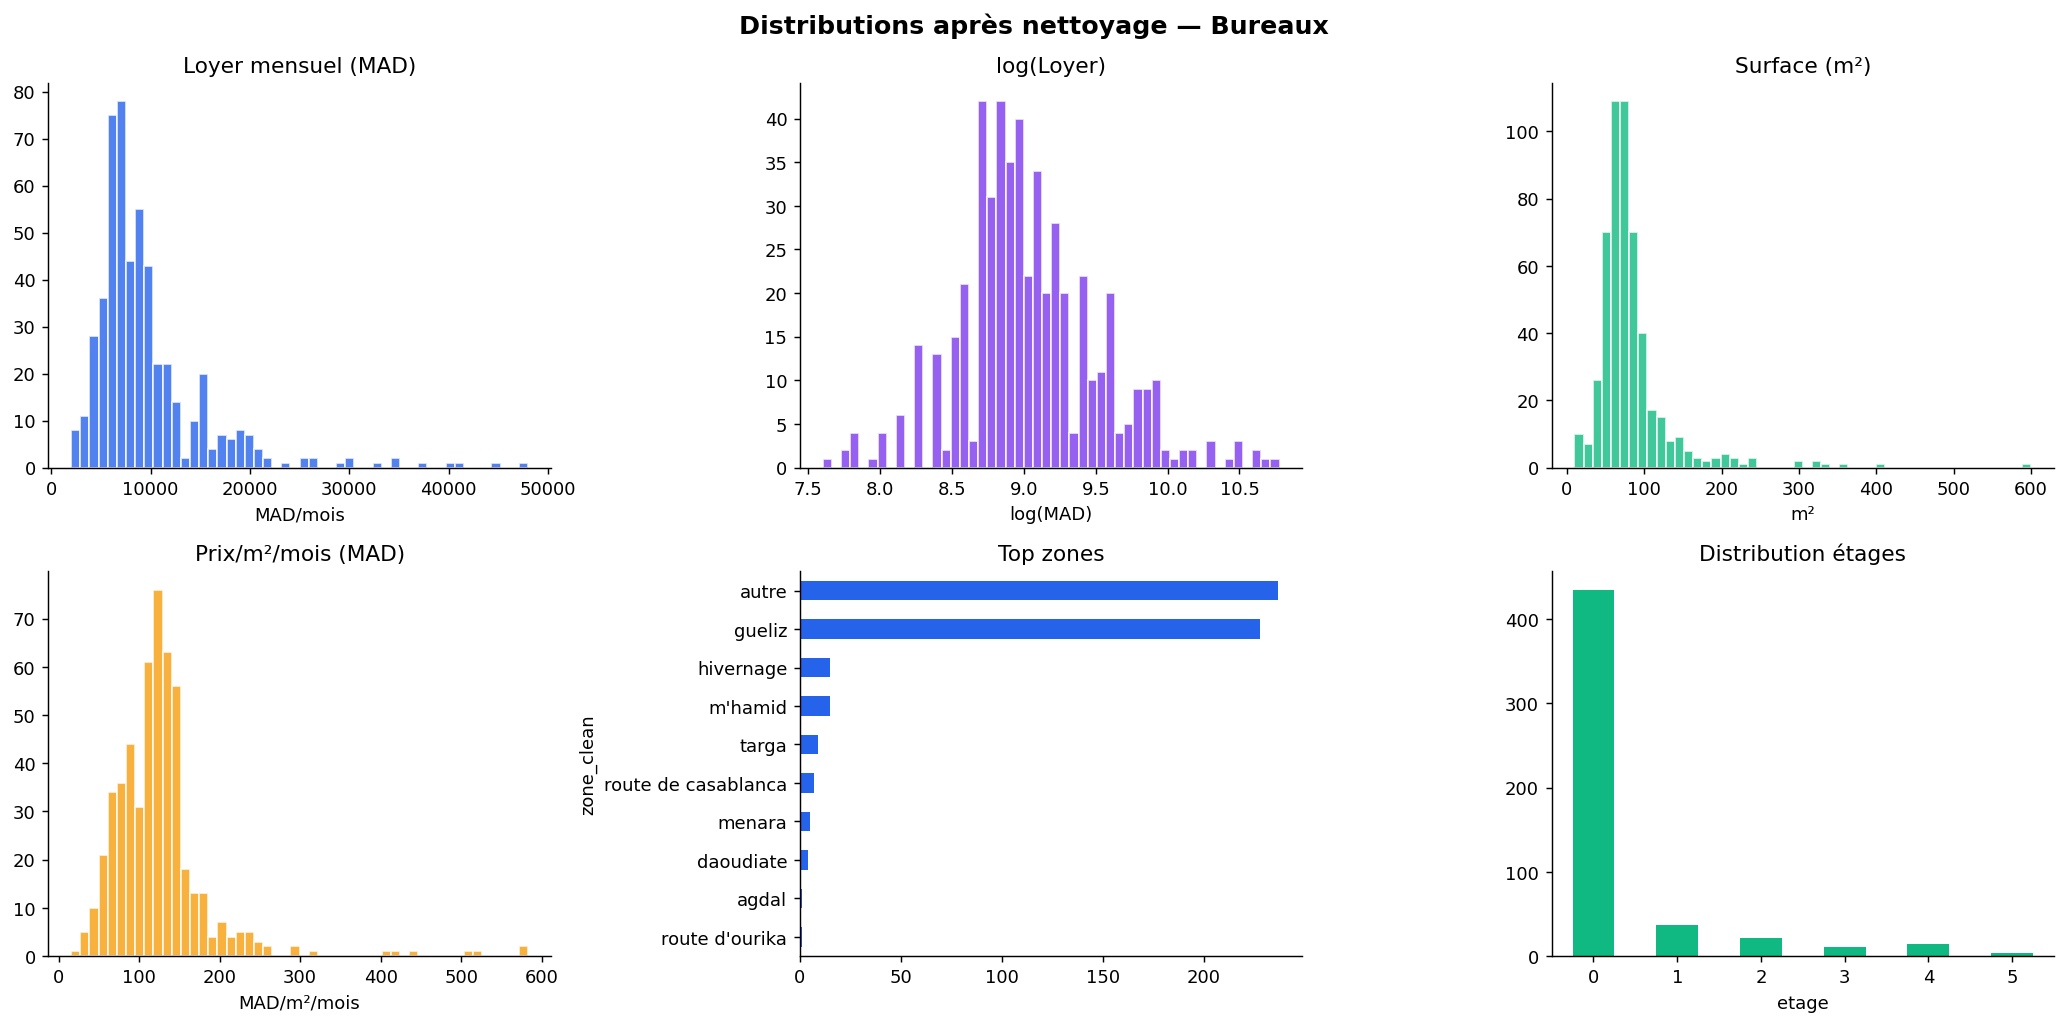

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Distributions après nettoyage — Bureaux", fontsize=14, fontweight="bold")

axes[0,0].hist(df["prix_num"], bins=50, color="#2563eb", alpha=0.8, edgecolor="white")
axes[0,0].set_title("Loyer mensuel (MAD)"); axes[0,0].set_xlabel("MAD/mois")

axes[0,1].hist(np.log(df["prix_num"]), bins=50, color="#7c3aed", alpha=0.8, edgecolor="white")
axes[0,1].set_title("log(Loyer)"); axes[0,1].set_xlabel("log(MAD)")

axes[0,2].hist(df["surface_num"], bins=50, color="#10b981", alpha=0.8, edgecolor="white")
axes[0,2].set_title("Surface (m²)"); axes[0,2].set_xlabel("m²")

axes[1,0].hist(df["prix_m2"], bins=50, color="#f59e0b", alpha=0.8, edgecolor="white")
axes[1,0].set_title("Prix/m²/mois (MAD)"); axes[1,0].set_xlabel("MAD/m²/mois")

df["zone_clean"].value_counts().head(10).plot(kind="barh", ax=axes[1,1], color="#2563eb")
axes[1,1].set_title("Top zones"); axes[1,1].invert_yaxis()

df["etage"].value_counts().sort_index().plot(kind="bar", ax=axes[1,2], color="#10b981")
axes[1,2].set_title("Distribution étages"); axes[1,2].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()


### 2.1 Loyer médian par zone

In [7]:
zone_stats = df.groupby("zone_clean").agg(
    nb=("prix_num","count"),
    loyer_median=("prix_num","median"),
    pm2_median=("prix_m2","median"),
    surface_mediane=("surface_num","median"),
).sort_values("loyer_median", ascending=False)
print(zone_stats.to_string())


                      nb  loyer_median  pm2_median  surface_mediane
zone_clean                                                         
route de casablanca    7       10000.0  126.984127             78.0
hivernage             15        9000.0  110.000000             88.0
gueliz               228        8855.0  129.411765             70.0
targa                  9        8500.0  113.888889             84.0
autre                237        7500.0  113.636364             70.0
agdal                  1        7000.0  184.210526             38.0
m'hamid               15        6500.0   76.470588             75.0
menara                 5        6150.0  298.900000             30.0
route d'ourika         1        6000.0   54.545455            110.0
daoudiate              4        5700.0   63.068182             88.0


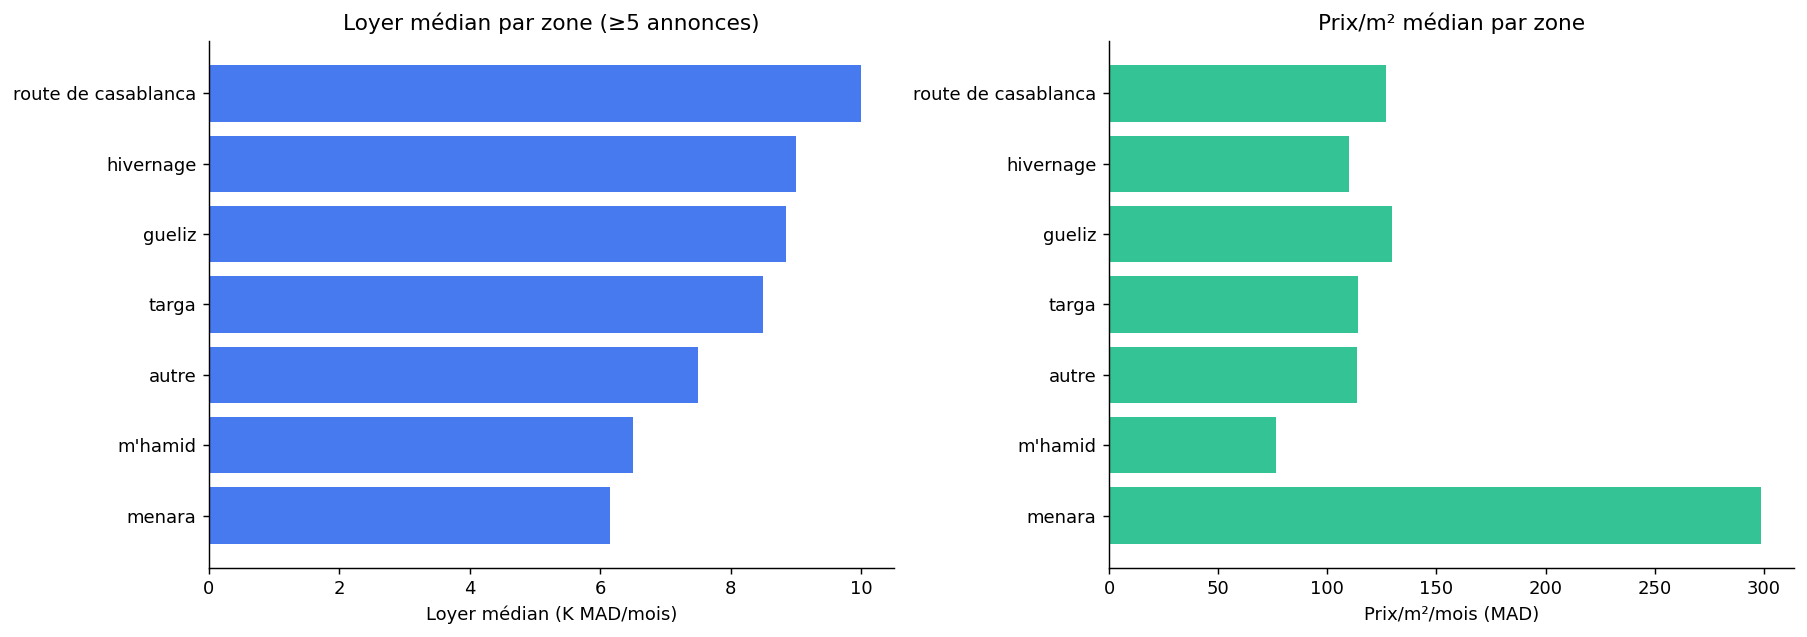

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top = zone_stats[zone_stats["nb"] >= 5].sort_values("loyer_median")
axes[0].barh(top.index, top["loyer_median"] / 1e3, color="#2563eb", alpha=0.85)
axes[0].set_xlabel("Loyer médian (K MAD/mois)"); axes[0].set_title("Loyer médian par zone (≥5 annonces)")
axes[1].barh(top.index, top["pm2_median"], color="#10b981", alpha=0.85)
axes[1].set_xlabel("Prix/m²/mois (MAD)"); axes[1].set_title("Prix/m² médian par zone")
plt.tight_layout(); plt.show()


### 2.2 Keywords NLP & Équipements

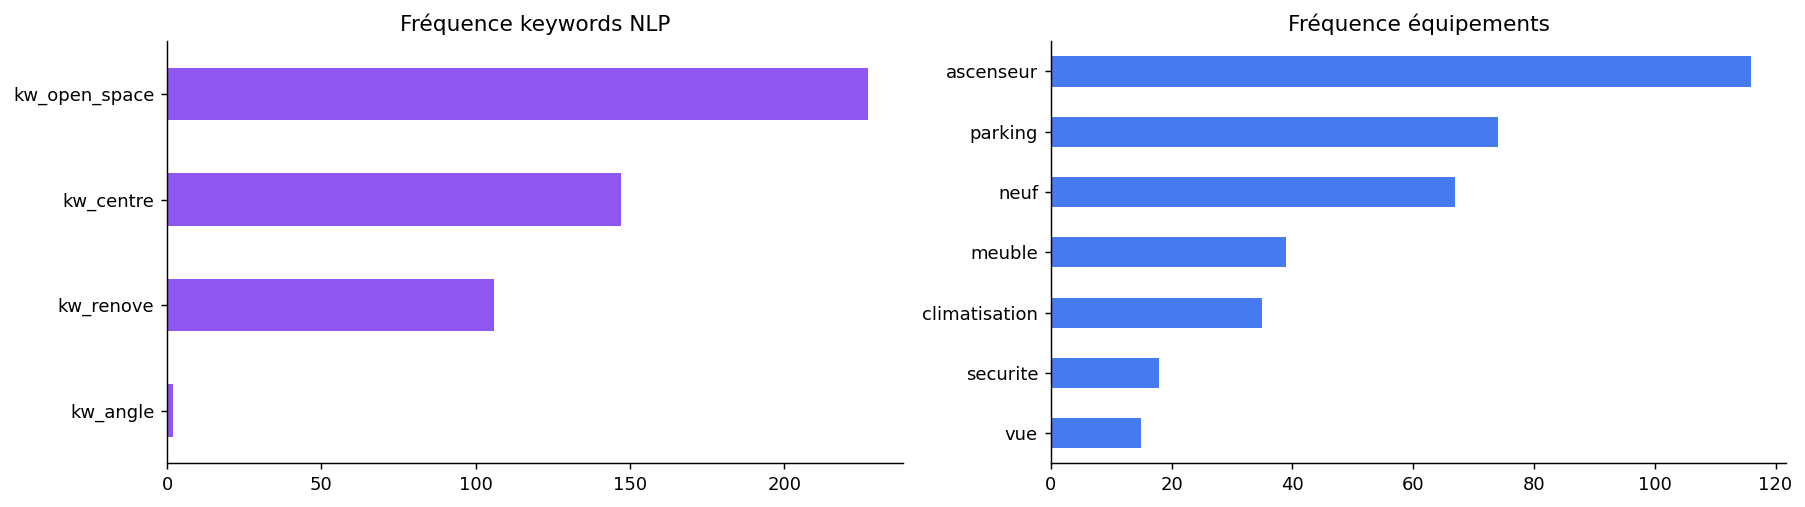

In [9]:
kw_cols = [c for c in BINARY_FEATURES if c.startswith("kw_")]
eq_cols = [c for c in BINARY_FEATURES if not c.startswith("kw_")]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df[kw_cols].sum().sort_values(ascending=True).plot(kind="barh", ax=axes[0], color="#7c3aed", alpha=0.85)
axes[0].set_title("Fréquence keywords NLP")
df[eq_cols].sum().sort_values(ascending=True).plot(kind="barh", ax=axes[1], color="#2563eb", alpha=0.85)
axes[1].set_title("Fréquence équipements")
plt.tight_layout(); plt.show()


## 3. Split train/test & Feature Engineering

In [10]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(df, test_size=0.2, random_state=42)
print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"\nFeatures : {len(stats['feature_cols'])} total")
print(f"  Numériques    : {len(stats['numeric_cols'])}")
print(f"  Binaires      : {len(stats['binary_cols'])}")
print(f"  Catégorielles : {len(stats['categorical_cols'])}")


   Train : 417 | Test : 105
Train : (417, 25) | Test : (105, 25)

Features : 25 total
  Numériques    : 12
  Binaires      : 11
  Catégorielles : 2


## 4. Entraînement XGBoost (défaut)

In [11]:
pipeline_default = build_pipeline(stats)
pipeline_default = train(pipeline_default, X_train, y_train)
metrics_default = evaluate(pipeline_default, X_train, X_test, y_train, y_test)


 Entraînement...

  MÉTRIQUES — BUREAUX LOCATION
  R² train        : 0.997
  R² test         : 0.954
  MAPE            : 6.1%
  MAD loyer       : 295 MAD/mois
  CV R² (5-fold)  : 0.931 ± 0.031


## 5. Optimisation Hyperparamètres — Optuna

In [12]:
best_params = tune_hyperparams(X_train, y_train, stats, n_trials=40)
print("\nMeilleurs hyperparamètres :")
for k, v in best_params.items():
    print(f"  {k}: {v}")


🔍 Tuning hyperparamètres (40 trials)...
   Meilleur CV R² : 0.932 | Params : {'n_estimators': 635, 'max_depth': 3, 'learning_rate': 0.020587566393543148, 'subsample': 0.9232940436435039, 'colsample_bytree': 0.7507294012653654, 'min_child_weight': 5, 'reg_alpha': 0.02484357127274604, 'reg_lambda': 1.310420023193901}

Meilleurs hyperparamètres :
  n_estimators: 635
  max_depth: 3
  learning_rate: 0.020587566393543148
  subsample: 0.9232940436435039
  colsample_bytree: 0.7507294012653654
  min_child_weight: 5
  reg_alpha: 0.02484357127274604
  reg_lambda: 1.310420023193901


In [13]:
pipeline_tuned = build_pipeline(stats, best_params)
pipeline_tuned = train(pipeline_tuned, X_train, y_train)
metrics_tuned  = evaluate(pipeline_tuned, X_train, X_test, y_train, y_test)
stats["mode"]  = metrics_tuned["mode"]


 Entraînement...

  MÉTRIQUES — BUREAUX LOCATION
  R² train        : 0.993
  R² test         : 0.948
  MAPE            : 6.7%
  MAD loyer       : 365 MAD/mois
  CV R² (5-fold)  : 0.932 ± 0.025


### 5.1 Comparaison défaut vs tuné

In [14]:
import pandas as pd
comparison = pd.DataFrame({
    "Défaut": {k: metrics_default.get(k) for k in ["r2_test","mape","cv_mean"]},
    "Optuna": {k: metrics_tuned.get(k)   for k in ["r2_test","mape","cv_mean"]},
}).rename(index={"r2_test":"R² test","mape":"MAPE (%)","cv_mean":"CV R² (mean)"})
print(comparison.round(4).to_string())


              Défaut  Optuna
R² test       0.9535  0.9479
MAPE (%)      6.0669  6.7412
CV R² (mean)  0.9314  0.9318


## 6. Visualisations

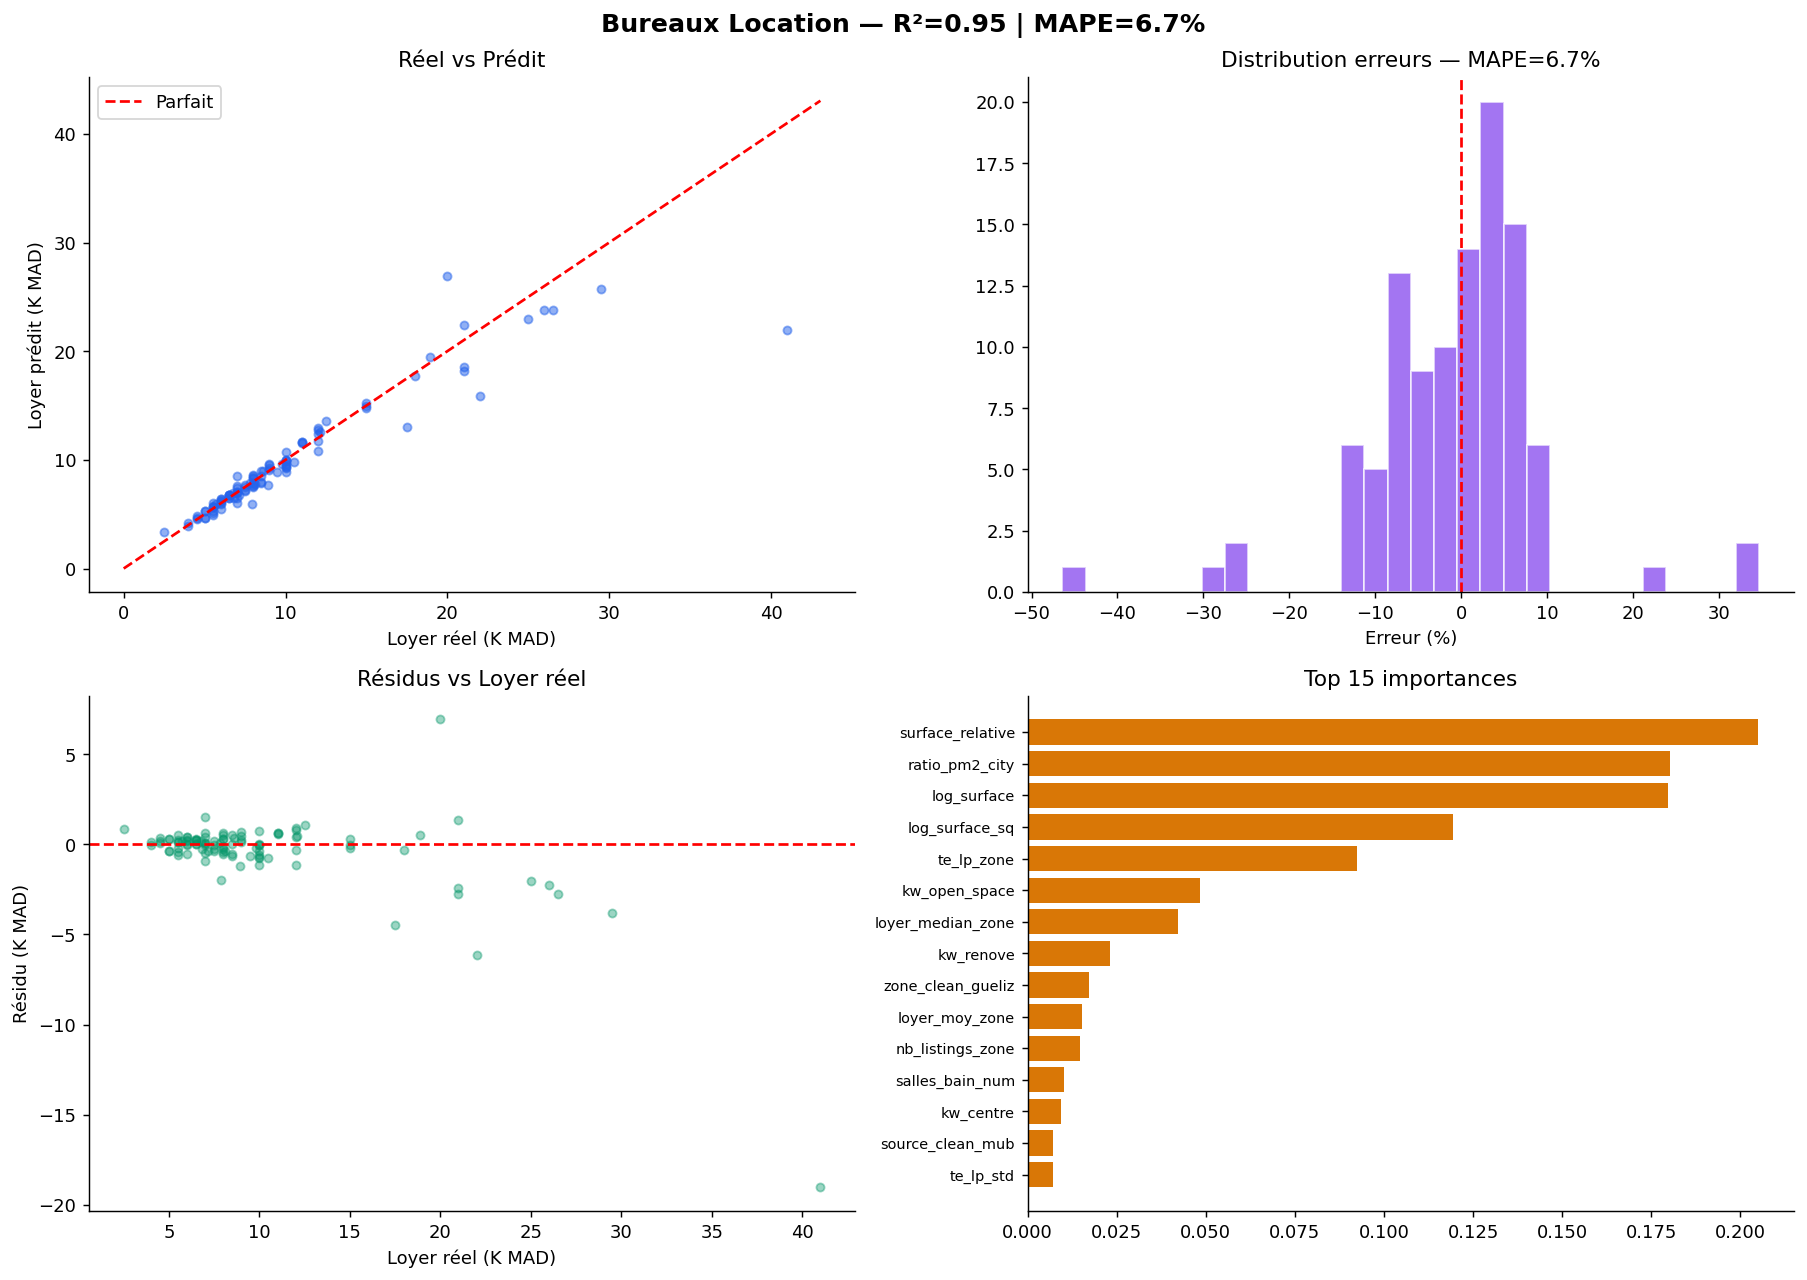

In [15]:
from pathlib import Path
save_dir = Path.cwd()
plot_results(pipeline_tuned, X_test, y_test, metrics_tuned, save_dir=save_dir)


### 6.1 Analyse des erreurs par zone

In [16]:
import numpy as np
y_pred_te = pipeline_tuned.predict(X_test)
prix_reel = np.exp(y_test)
prix_pred = np.exp(y_pred_te)
pct_err   = np.abs((prix_pred - prix_reel) / prix_reel) * 100

df_err = df_test.copy()
df_err["pct_err"] = pct_err
err_by_zone = df_err.groupby("zone_clean").agg(
    n=("pct_err","count"),
    mape_zone=("pct_err","mean"),
    loyer_med=("prix_num","median"),
).sort_values("mape_zone", ascending=False)
print("Erreurs par zone (≥3 annonces) :")
print(err_by_zone[err_by_zone["n"] >= 3].round(1).to_string())


Erreurs par zone (≥3 annonces) :
             n  mape_zone  loyer_med
zone_clean                          
autre       45        6.3     7800.0
gueliz      50        5.7     8500.0
m'hamid      5        4.8     5500.0


## 7. Prédictions exemples

In [17]:
exemples = [
    {"surface_num": 50,  "zone_clean": "Guéliz",  "etage": 1, "parking": 0, "climatisation": 1,
     "titre": "Bureau climatisé Guéliz centre"},
    {"surface_num": 100, "zone_clean": "Guéliz",  "etage": 3, "parking": 1, "ascenseur": 1, "climatisation": 1,
     "titre": "Plateau bureau climatisé Guéliz angle"},
    {"surface_num": 200, "zone_clean": "gueliz",  "etage": 0, "parking": 1, "securite": 1,
     "titre": "Open space lumineux Guéliz"},
    {"surface_num": 70,  "zone_clean": "autre",   "etage": 0,
     "titre": "Bureau Marrakech périphérie"},
    {"surface_num": 150, "zone_clean": "hivernage","etage": 2, "parking": 1, "climatisation": 1, "securite": 1,
     "titre": "Bureau haut standing Hivernage résidence"},
]
for ex in exemples:
    predict_price(pipeline_tuned, ex, stats)



 Bureaux location : 7,000 MAD/mois | 140.0 MAD/m²/mois

 Bureaux location : 10,600 MAD/mois | 106.0 MAD/m²/mois

 Bureaux location : 16,100 MAD/mois | 80.4 MAD/m²/mois

 Bureaux location : 8,000 MAD/mois | 114.0 MAD/m²/mois

 Bureaux location : 14,100 MAD/mois | 93.8 MAD/m²/mois


## 8. Sauvegarde du modèle

In [18]:
import joblib
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"pipeline": pipeline_tuned, "stats": stats}, MODEL_PATH)
print(f" Modèle sauvegardé : {MODEL_PATH}")

loaded = joblib.load(MODEL_PATH)
test_pred = np.exp(loaded["pipeline"].predict(X_test[:3]))
print(f"   Vérification — 3 prédictions : {test_pred.round(0)} MAD/mois")


 Modèle sauvegardé : /home/nouhayla/Desktop/stage/gateone-deploy/model_training/models/xgb_bureaux_location.pkl
   Vérification — 3 prédictions : [9404. 7670. 9483.] MAD/mois


## 9. Résumé

In [19]:
print("=" * 55)
print("  RÉSUMÉ — BUREAUX LOCATION v1")
print("=" * 55)
print(f"  Données brutes         : {df_raw.shape[0]} annonces")
print(f"  Après nettoyage        : {df.shape[0]} annonces")
print(f"  Features totales       : {len(stats['feature_cols'])}")
print(f"  R² test (Optuna)       : {metrics_tuned['r2_test']:.3f}")
print(f"  MAPE test              : {metrics_tuned['mape']:.1f}%")
print(f"  CV R² (5-fold)         : {metrics_tuned['cv_mean']:.3f} ± {metrics_tuned['cv_std']:.3f}")
print(f"  MAD loyer              : {metrics_tuned['mad']:,.0f} MAD/mois")
print(f"  Mode prédiction        : {stats['mode']}")
print("=" * 55)
print()
print("Seuils de nettoyage :")
print("  - Prix    : 1 000 – 100 000 MAD/mois")
print("  - Surface : 10 – 2 000 m²")
print("  - Prix/m² : 10 – 2 000 MAD/m²/mois")
print()
print("Features clés :")
print("  - Target encoding par zone")
print("  - Surface relative dans la zone")
print("  - NLP : angle, centre, open_space, rénové")
print("  - Équipements : parking, ascenseur, clim, sécurité")


  RÉSUMÉ — BUREAUX LOCATION v1
  Données brutes         : 715 annonces
  Après nettoyage        : 522 annonces
  Features totales       : 25
  R² test (Optuna)       : 0.948
  MAPE test              : 6.7%
  CV R² (5-fold)         : 0.932 ± 0.025
  MAD loyer              : 365 MAD/mois
  Mode prédiction        : point

Seuils de nettoyage :
  - Prix    : 1 000 – 100 000 MAD/mois
  - Surface : 10 – 2 000 m²
  - Prix/m² : 10 – 2 000 MAD/m²/mois

Features clés :
  - Target encoding par zone
  - Surface relative dans la zone
  - NLP : angle, centre, open_space, rénové
  - Équipements : parking, ascenseur, clim, sécurité
